In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
!pip install bioinfokit
from bioinfokit.visuz import cluster

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for bioinfokit: filename=bioinfokit-2.1.4-py3-none-any.whl size=59220 sha256=1c994e432cb27b57f25e5924eabf83d499911d7d8f3d63988c7b9a52da6d5fd9
  Stored in directory: /root/.cache/pip/wheels/83/cd/9c/8605a43f2310bfb74df791d943a9b3aef65377ed484de98bdc
Successfully built bioinfokit


In [ ]:
df1 = pd.read_csv('/content/PCA_a.csv') #encoding= 'unicode_escape')   #讀取資料
df1.isnull().values  #缺失值
~df1.applymap(np.isreal).values  #非數字
#print(df1)
# df1 = 原始excel
df2 = df1.drop(['Ch01','Ch05','Ch08','Ch09','Ch10','Ch11','Ch12','Ch14','Ch18','Ch19','Ch20','Ch21',
                'Ch06','Ch15','Ch22','Ch24','Ch26'],axis=1) #刪掉一些貢獻性不高的特徵
#print(df2) #只留下定量

<ipython-input-9-b2fc765fe088>:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ~df1.applymap(np.isreal).values  #非數字


          Ch01-1      Ch02      Ch03      Ch04      Ch07      Ch13      Ch16  \
Ch01-1  1.000000 -0.529929 -0.178335 -0.616444 -0.448400 -0.141178 -0.256457   
Ch02   -0.529929  1.000000  0.357449  0.829946  0.633294  0.114827  0.482207   
Ch03   -0.178335  0.357449  1.000000  0.402853  0.401943  0.265366  0.263724   
Ch04   -0.616444  0.829946  0.402853  1.000000  0.675517  0.090242  0.564917   
Ch07   -0.448400  0.633294  0.401943  0.675517  1.000000  0.127342  0.598970   
Ch13   -0.141178  0.114827  0.265366  0.090242  0.127342  1.000000  0.128095   
Ch16   -0.256457  0.482207  0.263724  0.564917  0.598970  0.128095  1.000000   
Ch17   -0.145835  0.338631  0.170542  0.256282  0.262577  0.140181  0.213774   
Ch23    0.078962 -0.121485  0.179683 -0.110951  0.037382  0.105274  0.073997   
Ch25   -0.209014  0.233468  0.056773  0.285315  0.368615  0.160448  0.250736   
Ch27    0.099687 -0.118652  0.107591 -0.126963 -0.036092  0.263233  0.054363   
Ch28   -0.106231  0.104672  0.047268  0.

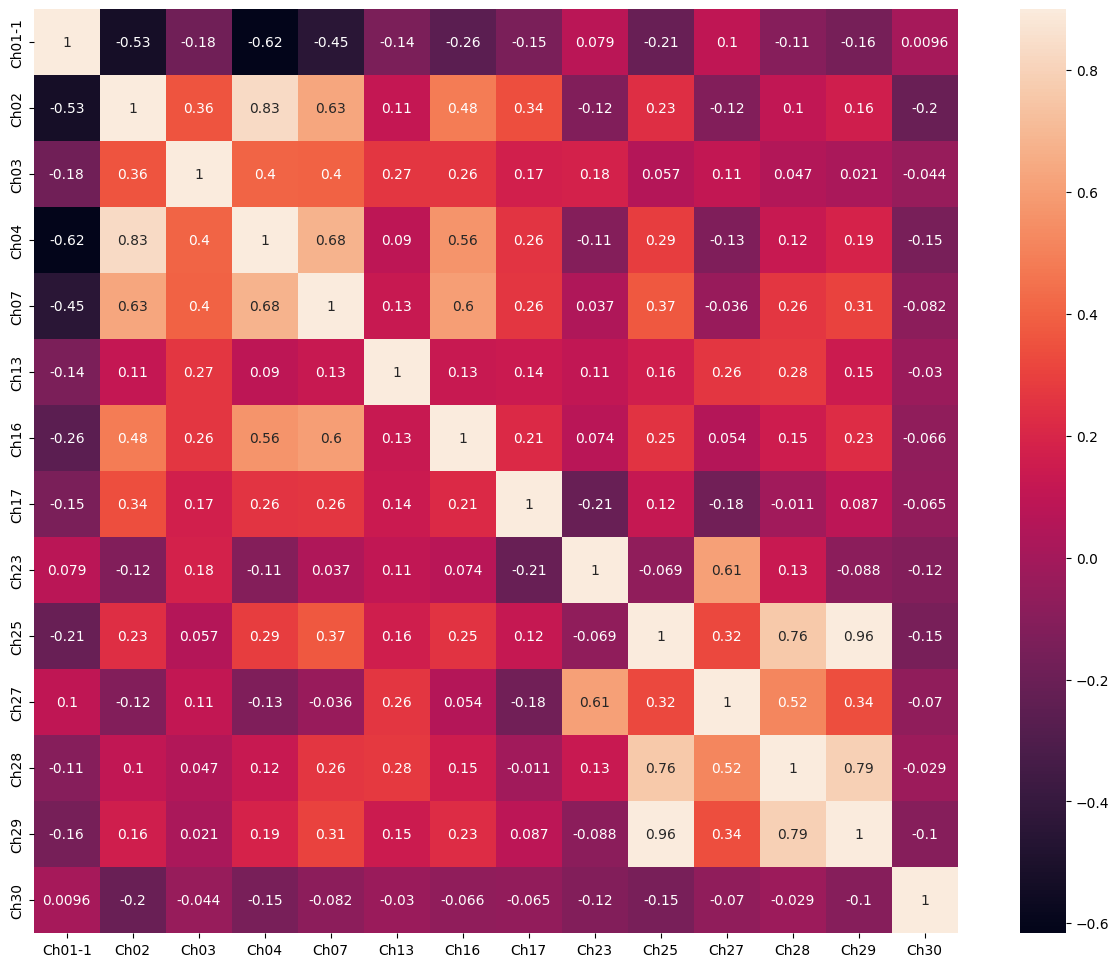

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df2.select_dtypes(include=[float, int]).corr(method='pearson', min_periods=1)

#correlation_matrix = df2.corr(method='pearson', min_periods=1)  #以皮爾森的方式找相關係數，所有對角值均為1.0
print(correlation_matrix)
#correlation matrix
f, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(correlation_matrix, vmax=.9, cbar=True, annot=True,square=True)  #放大圖片
plt.savefig("correlation_matrix.pdf", format='pdf', bbox_inches='tight')

In [ ]:
#from sklearn.preprocessing import OneHotEncoder
data_dum_1 = pd.get_dummies(df2) #data_dum_1留下全部分岔
data_dum_1 = df2.fillna(df2.mean(numeric_only=True))

#data_dum = pd.get_dummies(df2)     #編碼
#dfonehot = pd.DataFrame(data_dum)
'''
data_dum = pd.get_dummies(df2)     #編碼

dfonehot = pd.DataFrame(data_dum)
dfonehot = dfonehot.fillna(df2.mean(numeric_only=True))  #缺失值填補平均數
'''

print(data_dum_1)
#print(dfonehot)
data_dum_1.head()

              ID  Ch01-1        Ch02  Ch03   Ch04       Ch07  Ch13     Ch16  \
0      2019_0001       1  136.000000   5.2  47.07  18.900000   0.0  8.28000   
1      2019_0002       1   95.200000   3.4  32.87  12.100000   0.0  5.68000   
2      2019_0003       1  120.300000   7.4  42.57  23.600000  21.7  8.66000   
3      2019_0004       1  109.600000   4.2  37.93  15.100000  10.6  7.92000   
4      2019_0005       1  134.800000   5.1  46.63  16.600000   0.0  5.86000   
..           ...     ...         ...   ...    ...        ...   ...      ...   
102  2020_1010_a       5   52.760000   2.4  12.83   8.960000   0.0  7.73515   
103  2020_1011_a       4   54.800000   2.4  14.85   9.150000   0.0  4.85500   
104  2020_1012_a       5   46.300000   3.2  15.13   8.840000   0.0  7.73515   
105  2020_1013_a       3   59.400000   2.4  15.67  10.633333   0.0  5.26000   
106  2020_1015_a       3   82.866667   9.7  24.73  10.433333   0.0  6.10000   

         Ch17  Ch23  Ch25  Ch27  Ch28  Ch29  Ch30 C

,ID,Ch01-1,Ch02,Ch03,Ch04,Ch07,Ch13,Ch16,Ch17,Ch23,Ch25,Ch27,Ch28,Ch29,Ch30,Chcolor
0,2019_0001,1,136.0,5.2,47.07,18.9,0.0,8.28,6.96,1.77,0.91,1.26,1.10,0.75,4.06,R
1,2019_0002,1,95.2,3.4,32.87,12.1,0.0,5.68,0.30,1.89,0.93,1.50,1.18,0.82,4.30,B
2,2019_0003,1,120.3,7.4,42.57,23.6,21.7,8.66,3.72,1.73,0.97,1.36,1.28,0.90,6.40,Y
3,2019_0004,1,109.6,4.2,37.93,15.1,10.6,7.92,2.69,1.68,0.91,1.27,1.20,0.82,4.40,Y
4,2019_0005,1,134.8,5.1,46.63,16.6,0.0,5.86,1.88,1.70,1.00,1.23,1.19,0.83,3.33,B


[0.28712336 0.18446915 0.11715469 0.076534   0.07324078 0.06560956
 0.04828294 0.04454797 0.02667971 0.02503833 0.01946487 0.01504891
 0.01423518]


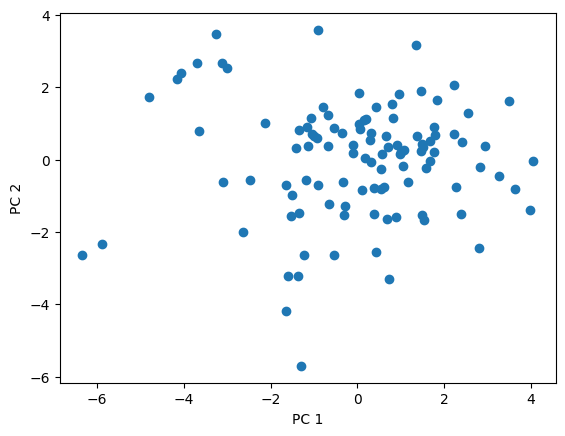

前90%的的PC值（到PC9）: [0.28712336 0.18446915 0.11715469 0.076534   0.07324078 0.06560956
 0.04828294 0.04454797 0.02667971]
特徵向量： [[-0.28291794  0.35238796  0.21911409  0.34256163  0.38373618  0.16252811
   0.28677443  0.15583592  0.00618358  0.3604709   0.10729606  0.29703574
   0.33262886 -0.09932435]
 [ 0.22728193 -0.29758246 -0.13836079 -0.28117618 -0.17491602  0.1118965
  -0.1091039  -0.19671415  0.24121509  0.31333404  0.45994911  0.41952717
   0.35183923 -0.01254123]
 [ 0.01527201  0.03969667  0.40626554  0.02835946  0.08613357  0.24371696
   0.14298529 -0.11853502  0.61428993 -0.30275327  0.36119727 -0.1262073
  -0.32702713 -0.09312645]
 [ 0.23060326 -0.12191737  0.2279248  -0.22672549 -0.0363415   0.55300996
   0.09310862  0.54939494 -0.20300444 -0.04189202 -0.03527652  0.03629121
  -0.00772081  0.40666025]
 [-0.37672922 -0.06023476  0.03749811  0.13760448  0.05214016  0.03491502
  -0.10588127 -0.42474155 -0.00896804 -0.04857197  0.03089348  0.09999964
  -0.02040704  0.79040587]
 [

In [ ]:
# Standardlization
from sklearn.preprocessing import StandardScaler

# X改成這樣就可以了
X = data_dum_1.iloc[:, 1:15].values #去除了去除了id那一行
#print(X)

sc = StandardScaler()
X_train_std = sc.fit_transform(X)

#取最佳pca降維
pcan = PCA(n_components='mle')
X_train_pca = pcan.fit_transform(X_train_std)
print(pcan.explained_variance_ratio_)
#pcan的結果和pca9.explained_variance_ratio_是一樣的，只是9只顯示了９個
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1])
#這邊看pc，可以改成 X_train_pca[:, 0], X_train_pca[:, 2]，這樣可以看這樣可以看PC1.3的結果
plt.xlabel('PC 1')
plt.ylabel('PC 2')

plt.show()

pca9 = PCA(0.9)
X_train_pca = pca9.fit_transform(X_train_std)
print('前90%的的PC值（到PC9）:',pca9.explained_variance_ratio_)
print('特徵向量：',pca9.components_)

In [ ]:
# # X_train_pca = pcan.fit_transform(X_train_std)
# pca_out = PCA('mle').fit(X_train_std)
# loadings = pca_out.components_
# num_pc = pca_out.n_features_
# pc_list = ["PC"+str(i) for i in list(range(1, num_pc+1))]
# loadings_df = data_dum_1.iloc[:, 1:].from_dict(dict(zip(pc_list, loadings)))
# loadings_df['variable'] = data_dum_1.iloc[:, 1:].columns.values
# loadings_df = loadings_df.set_index('variable')
# loadings_df
# # output

from sklearn.decomposition import PCA

# 執行 PCA with MLE
pca_out = PCA(n_components='mle').fit(X_train_std)

# 主成分權重矩陣（每個 PC 的 loading）
loadings = pca_out.components_

# 正確取得主成分數量
num_pc = pca_out.n_components_

# 建立 PC 名稱清單
pc_list = ["PC"+str(i) for i in range(1, num_pc+1)]

# 建立 loadings dataframe
loadings_df = pd.DataFrame(loadings.T, columns=pc_list)
loadings_df['variable'] = data_dum_1.columns[1:15]  # 若第一欄為 ID，可跳過
loadings_df = loadings_df.set_index('variable')

loadings_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
variable,,,,,,,,,,,,,
Ch01-1,-0.282918,0.227282,0.015272,0.230603,-0.376729,0.331453,0.286411,-0.292407,0.360391,0.405036,0.284682,-0.090515,-0.110458
Ch02,0.352388,-0.297582,0.039697,-0.121917,-0.060235,-0.042141,-0.075102,0.056327,0.607159,0.257919,-0.473192,-0.303843,-0.070844
Ch03,0.219114,-0.138361,0.406266,0.227925,0.037498,-0.059556,0.697079,-0.298182,-0.121568,-0.248260,-0.222586,-0.006357,0.098448
Ch04,0.342562,-0.281176,0.028359,-0.226725,0.137604,-0.206403,0.188535,0.076229,0.242770,-0.005951,0.764162,0.030142,-0.003291
Ch07,0.383736,-0.174916,0.086134,-0.036342,0.052140,0.300022,-0.042686,-0.071063,-0.409675,0.588190,-0.044180,0.388382,-0.216578


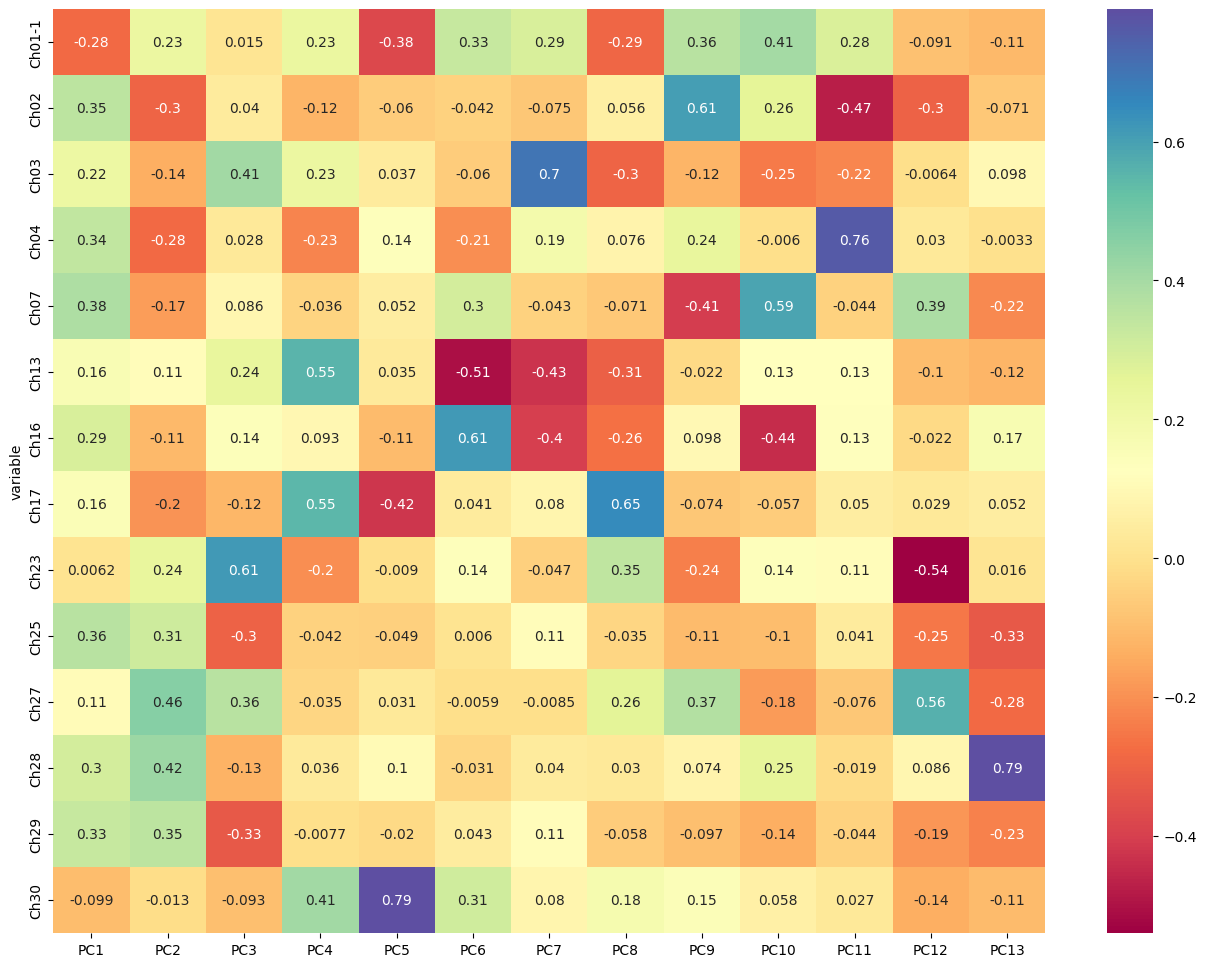

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
ax = plt.subplots(figsize=(16, 12))
ax = sns.heatmap(loadings_df, annot=True, cmap='Spectral')
plt.show()

In [ ]:
# 設定target
#target = df1['Ch01-1'].to_numpy()

In [ ]:
# get PCA loadings plots (2D and 3D)
# 2D

# 安裝 Arial 字體
!apt-get -y install ttf-mscorefonts-installer
import matplotlib.font_manager as fm


# 設定 matplotlib 預設字體為 Arial
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'


cluster.pcaplot(x=loadings[0], y=loadings[1], labels=data_dum_1.iloc[:, 1:15].columns.values,
    var1=round(pca_out.explained_variance_ratio_[0]*100, 2),
    var2=round(pca_out.explained_variance_ratio_[1]*100, 2), r = 700)
'''
# 3D
cluster.pcaplot(x=loadings[0], y=loadings[1], z=loadings[2],  labels=data_dum_1.iloc[:, 1:].columns.values,
    var1=round(pca_out.explained_variance_ratio_[0]*100, 2), var2=round(pca_out.explained_variance_ratio_[1]*100, 2),
    var3=round(pca_out.explained_variance_ratio_[2]*100, 2))
'''

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ttf-mscorefonts-installer is already the newest version (3.8ubuntu2).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


'\n# 3D\ncluster.pcaplot(x=loadings[0], y=loadings[1], z=loadings[2],  labels=data_dum_1.iloc[:, 1:].columns.values, \n    var1=round(pca_out.explained_variance_ratio_[0]*100, 2), var2=round(pca_out.explained_variance_ratio_[1]*100, 2), \n    var3=round(pca_out.explained_variance_ratio_[2]*100, 2))\n'

In [ ]:
# get PC scores
pca_scores = PCA().fit_transform(X_train_std)

# get 2D biplot
cluster.biplot(cscore=pca_scores, loadings=loadings, labels=data_dum_1.iloc[:, 1:].columns.values,
                   var1=round(pca_out.explained_variance_ratio_[0]*100, 2),
                   var2=round(pca_out.explained_variance_ratio_[1]*100, 2),arrowcolor='dimgray', colordot ='lightcoral' ,
                              valphaarrow = 1, arrowlinewidth = 0.8, r = 700) #, colorlist = target)
               #colorlist=target 設定一下target
'''
# get 3D biplot
cluster.biplot(cscore=pca_scores, loadings=loadings, labels=data_dum_1.iloc[:, 1:].columns.values,
    var1=round(pca_out.explained_variance_ratio_[0]*100, 2), var2=round(pca_out.explained_variance_ratio_[1]*100, 2),
    var3=round(pca_out.explained_variance_ratio_[2]*100, 2))
'''

' \n# get 3D biplot\ncluster.biplot(cscore=pca_scores, loadings=loadings, labels=data_dum_1.iloc[:, 1:].columns.values, \n    var1=round(pca_out.explained_variance_ratio_[0]*100, 2), var2=round(pca_out.explained_variance_ratio_[1]*100, 2), \n    var3=round(pca_out.explained_variance_ratio_[2]*100, 2))\n'

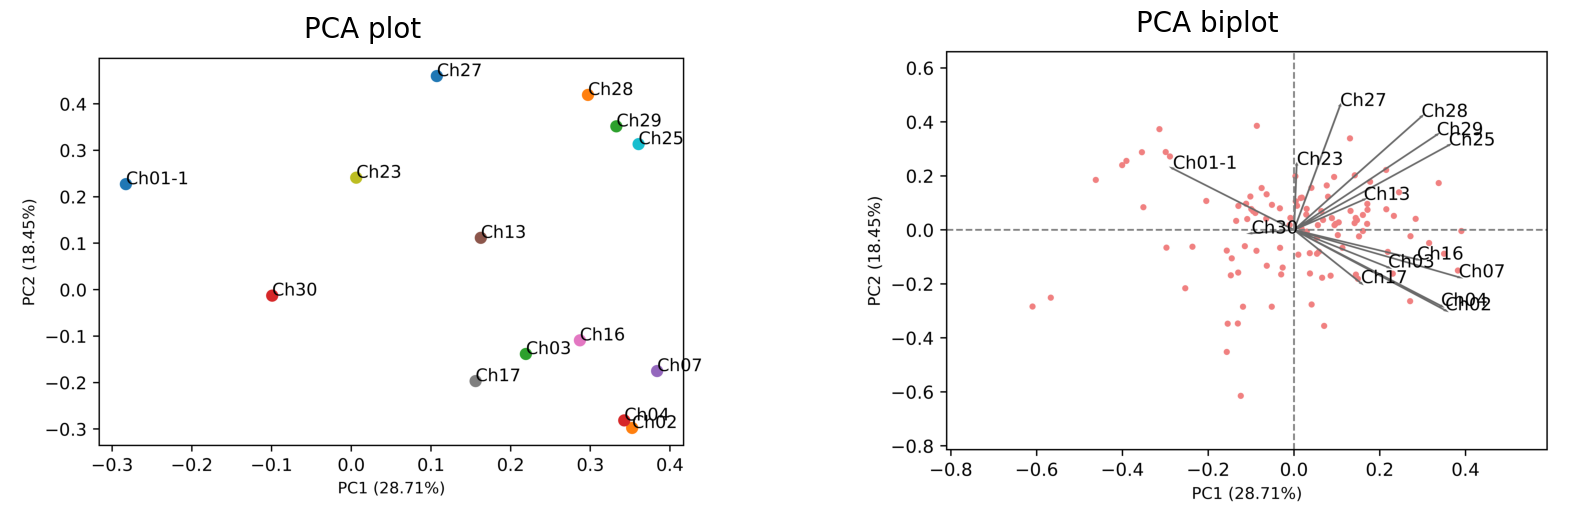

In [ ]:
from skimage.io import imread

plt.figure(figsize=(20,10))

pcaplot = imread('/content/pcaplot_2d.png')
biplot = imread('/content/biplot_2d.png')

plt.subplot(121), plt.imshow(pcaplot), plt.axis('off'), plt.title('PCA plot', size=20)
plt.subplot(122), plt.imshow(biplot), plt.axis('off'), plt.title('PCA biplot', size=20)
plt.savefig("pcaplot_biplot.pdf", format='pdf', bbox_inches='tight')

plt.show()